### Link prediction with node2vec (and logistic regression)

In [ ]:
import argparse
import numpy as np
import networkx as nx
import random
from gensim.models import Word2Vec, KeyedVectors

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, average_precision_score, precision_recall_curve


RANDOM_STATE = 0
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

Import data, train, validation, test split

In [ ]:
G_karate = nx.karate_club_graph() #simple graph for testing

amr_layerkg = nx.read_gexf(f'n2v_rgcn_kg/n2v_amr_layerkg.gexf') #amr layer graph for testing

wholekg = nx.read_gexf(f'n2v_rgcn_kg/n2v_wholekg.gexf')

sub_n2v = nx.read_gexf(f'n2v_rgcn_kg/subwholekg_n2v.gexf')

In [ ]:
def get_edgelists(G, test_prop, valid_prop):

    "This function takes the input graph and splits it into the training, validation and testing sets. It also writes a .edgelist file for the whole graph for node2vec implementation."


    def train_valid_test_split(G,test_prop, valid_prop):


        test_edges = random.sample(sorted(G.edges()), int(test_prop*G.number_of_edges()))
        test_graph = nx.edge_subgraph(G, test_edges)


        train_valid_graph = G.copy()
        train_valid_graph.remove_edges_from(test_edges)


        valid_edges = random.sample(sorted(train_valid_graph.edges()), int(valid_prop*train_valid_graph.number_of_edges()))
        valid_graph = nx.edge_subgraph(G, valid_edges)

        train_graph = train_valid_graph.copy()
        train_graph.remove_edges_from(valid_edges)

        print('Number of edges for full graph:', G.number_of_edges())
        print('Number of edges held out (testing set):',  len(test_edges))
        print('Number of edges held out (validation set):', len(valid_edges))
        print('Number of edges for training set:', train_graph.number_of_edges())


        return test_graph, valid_graph, train_graph

    test_graph, valid_graph, train_graph = train_valid_test_split(G, test_prop, valid_prop)

    nx.write_edgelist(G,'wholekg.edgelist')


    return test_graph, valid_graph, train_graph


In [ ]:
test_graph, valid_graph, train_graph = get_edgelists(amr_layerkg,0.3, 0.2)

Number of edges for full graph: 8923
Number of edges held out (testing set): 2676
Number of edges held out (validation set): 1249
Number of edges for training set: 4998


Creating embeddings for nodes of the graph using node2vec

In [ ]:
'''
Reference implementation of node2vec. 

Original author: Aditya Grover  (MAB's comments in green)

For more details, refer to the paper:
node2vec: Scalable Feature Learning for Networks
Aditya Grover and Jure Leskovec 
Knowledge Discovery and Data Mining (KDD), 2016
'''

"\nReference implementation of node2vec. \n\nOriginal author: Aditya Grover  (MAB's comments in green)\n\nFor more details, refer to the paper:\nnode2vec: Scalable Feature Learning for Networks\nAditya Grover and Jure Leskovec \nKnowledge Discovery and Data Mining (KDD), 2016\n"

In [ ]:
class Graph():
	def __init__(self, nx_G, is_directed, p, q):
		self.G = nx_G
		self.is_directed = is_directed
		self.p = p
		self.q = q

	def node2vec_walk(self, walk_length, start_node):
		'''
		Simulate a random walk starting from start node.
		'''
		G = self.G
		alias_nodes = self.alias_nodes
		alias_edges = self.alias_edges

		walk = [start_node]

		while len(walk) < walk_length:
			cur = walk[-1]
			cur_nbrs = sorted(G.neighbors(cur))
			if len(cur_nbrs) > 0:
				if len(walk) == 1:
					walk.append(cur_nbrs[alias_draw(alias_nodes[cur][0], alias_nodes[cur][1])])
				else:
					prev = walk[-2]
					next = cur_nbrs[alias_draw(alias_edges[(prev, cur)][0], alias_edges[(prev, cur)][1])]
					walk.append(next)
			else:
				break

		return walk

	def simulate_walks(self, num_walks, walk_length):
		'''
		Repeatedly simulate random walks from each node.
		'''
		G = self.G
		walks = []
		nodes = list(G.nodes())

		print('Walk iteration:')

		for walk_iter in range(num_walks):
			print(str(walk_iter+1), '/', str(num_walks))
			random.shuffle(nodes)
			for node in nodes:
				walks.append(self.node2vec_walk(walk_length=walk_length, start_node=node))

		return walks

	def get_alias_edge(self, src, dst):  #alias edges for edge between src -- immediate past node, dst -- current node
		'''
		Get the alias edge setup lists for a given edge.
		'''
		G = self.G
		p = self.p  #return parameter
		q = self.q	#in-out parameter 

		unnormalized_probs = []
		for dst_nbr in sorted(G.neighbors(dst)):
			if dst_nbr == src:
				unnormalized_probs.append(G[dst][dst_nbr]['weight']/p)  #if the neighbour picked is the one we just left (d_tx = 0)
			elif G.has_edge(dst_nbr, src):
				unnormalized_probs.append(G[dst][dst_nbr]['weight'])	#if the neighbour picked has a link with previous node (d_tx = 1)
			else:
				unnormalized_probs.append(G[dst][dst_nbr]['weight']/q)  #if none of both then automatically d_tx = 2 wrt previous node

		norm_const = sum(unnormalized_probs)

		normalized_probs =  [float(u_prob)/norm_const for u_prob in unnormalized_probs]  #normalising-- (pi_vx)/Z

		return alias_setup(normalized_probs)

	def preprocess_transition_probs(self):
		'''
		Preprocessing of transition probabilities for guiding the random walks.
		'''
		G = self.G
		is_directed = self.is_directed

		alias_nodes = {}
		for node in G.nodes():
			unnormalized_probs = [G[node][nbr]['weight'] for nbr in sorted(G.neighbors(node))]
			norm_const = sum(unnormalized_probs)
			normalized_probs =  [float(u_prob)/norm_const for u_prob in unnormalized_probs]
			alias_nodes[node] = alias_setup(normalized_probs)

		alias_edges = {}

		if is_directed:
			for edge in G.edges():
				alias_edges[edge] = self.get_alias_edge(edge[0], edge[1])
		else:
			for edge in G.edges():
				alias_edges[edge] = self.get_alias_edge(edge[0], edge[1])
				alias_edges[(edge[1], edge[0])] = self.get_alias_edge(edge[1], edge[0]) #save the reverse as well because its an undirected graph

		self.alias_nodes = alias_nodes
		self.alias_edges = alias_edges

		return

In [ ]:
def alias_setup(probs):
	'''
	Compute utility lists for non-uniform sampling from discrete distributions.
	Refer to https://hips.seas.harvard.edu/blog/2013/03/03/the-alias-method-efficient-sampling-with-many-discrete-outcomes/
	for details
	'''

	#helpful for understanding: https://www.keithschwarz.com/darts-dice-coins/
	
	K = len(probs)   #n 
	q = np.zeros(K)  #probs, U_i
	J = np.zeros(K, dtype=int)  #aliases, K_i

	smaller = []
	larger = []
	for kk, prob in enumerate(probs): #kk are index of 'columns', prob is the original prob assigned to the column
		q[kk] = K*prob  ## multiply prob by n
	if q[kk] < 1.0:  ## save which columns are underfull and which are overfull
		smaller.append(kk)  
	else:
		larger.append(kk)

	while len(smaller) > 0 and len(larger) > 0: ## while there is still an imbalance, because once one column is overfull, there must be one underfull to receive..
		small = smaller.pop()	
		large = larger.pop()  # pick a pair of small and large 

		J[small] = large  #let the alias of the small be the large
		q[large] = q[large] + q[small] - 1.0  #correct the prob of the large to account for the 'pour' i.e q_large - (1 - q_small)
		
		if q[large] < 1.0:
			smaller.append(large)  # assign large to its appropriate set. 
		else:
			larger.append(large)

	return J, q  #aliases only have index not probs.

In [ ]:
def alias_draw(J, q):
	'''
	Draw sample from a non-uniform discrete distribution using alias sampling.
	'''
	K = len(J)

	kk = int(np.floor(np.random.rand()*K))
	if np.random.rand() < q[kk]:
		return kk
	else:
		return J[kk]  ## at the end of the day the indices are what is returned to select a specific neighbour

In [ ]:
def parse_args():
	'''
	Parses the node2vec arguments.
	'''
	parser = argparse.ArgumentParser(description="Run node2vec.")

	parser.add_argument('--input', nargs='?', default= 'wholekg.edgelist',
	                    help='Input graph path')

	parser.add_argument('--output', nargs='?', default='embeddings.csv',
	                    help='Embeddings path')

	parser.add_argument('--dimensions', type=int, default=128,
	                    help='Number of dimensions. Default is 128.')

	parser.add_argument('--walk-length', type=int, default=80,
	                    help='Length of walk per source. Default is 80.')

	parser.add_argument('--num-walks', type=int, default=10,
	                    help='Number of walks per source. Default is 10.') #Changed from 10

	parser.add_argument('--window-size', type=int, default=10,
                    	help='Context size for optimization. Default is 10.') #Changed from 10

	parser.add_argument('--iter', default=1, type=int,
                      help='Number of epochs in SGD') #Changed from 1

	parser.add_argument('--workers', type=int, default=8,
	                    help='Number of parallel workers. Default is 8.')

	parser.add_argument('--p', type=float, default=2,
	                    help='Return hyperparameter. Default is 1.') #Changed from 1

	parser.add_argument('--q', type=float, default=1,
	                    help='Inout hyperparameter. Default is 1.')

	parser.add_argument('--weighted', dest='weighted', action='store_false',
	                    help='Boolean specifying (un)weighted. Default is unweighted.')
	
	parser.add_argument('--unweighted', dest='unweighted', action='store_true')
	parser.set_defaults(weighted=False)

	parser.add_argument('--directed', dest='directed', action='store_true',
	                    help='Graph is (un)directed. Default is undirected.')
	parser.add_argument('--undirected', dest='undirected', action='store_false')
	parser.set_defaults(directed=False)

	return parser.parse_known_args()

In [ ]:
def read_graph():
	'''
	Reads the input network in networkx.
	'''
	if args.weighted:
		G = nx.read_edgelist(args.input, nodetype = int, data=(('weight',float),), create_using=nx.DiGraph())
	else:
		G = nx.read_edgelist(args.input, nodetype = int, create_using=nx.DiGraph())
		for edge in G.edges():
			G[edge[0]][edge[1]]['weight'] = 1

	if not args.directed:
		G = G.to_undirected()

	return G

In [ ]:
def learn_embeddings(walks):
	'''
	Learn embeddings by optimizing the Skipgram objective using SGD.
	'''
	walks = [list(map(str, walk)) for walk in walks]
	model = Word2Vec(walks, vector_size=args.dimensions, window=args.window_size, min_count=0, sg=1, workers=args.workers, epochs=args.iter)
	model.wv.save_word2vec_format(args.output)
	
	return

In [ ]:
#dict(wholekg.nodes('node_name'))

In [ ]:
def main(args):
	'''
	Pipeline for representational learning for all nodes in a graph.
	'''
	nx_G = read_graph()
	G = Graph(nx_G, args.directed, args.p, args.q)
	G.preprocess_transition_probs()
	walks = G.simulate_walks(args.num_walks, args.walk_length)
	learn_embeddings(walks)

if __name__ == "__main__":
	args, unknown = parse_args()
	main(args)


Walk iteration:
1 / 10
2 / 10
3 / 10
4 / 10
5 / 10
6 / 10
7 / 10
8 / 10
9 / 10
10 / 10


Some credit to [Lucashu1's Github](https://github.com/lucashu1/link-prediction/blob/master/node2vec.ipynb) for link prediction pipeline steps

In [ ]:
import pandas as pd
node_emb = pd.read_csv('embeddings.csv', delimiter=' ', header=None, names = range(args.dimensions+1), index_col=0).fillna(0)

In [ ]:
# Edge embedding for (v1, v2) = Hadamard product of node embeddings for v1, v2 (as is done in node2vec paper)

def get_edge_embeddings(edge_list):
    embs = []
    for edge in list(edge_list):
        edge_emb = np.multiply(np.array(node_emb.loc[int(edge[0]),:]), np.array(node_emb.loc[int(edge[1]),:]))
        embs.append(edge_emb)
    embs = np.array(embs)
    return embs

Creating the positive (actual edges) and negative (false edges) embeddings and labels 

In [ ]:
#positive_train_edge_embs = get_edge_embeddings(train_graph.edges())
#negative_train_edge_embs = get_edge_embeddings(nx.non_edges(train_graph))
#train_edge_embs = np.concatenate((positive_train_edge_embs,negative_train_edge_embs))
#train_labels = np.concatenate((np.ones(len(positive_train_edge_embs)), np.zeros(len(negative_train_edge_embs))))

#np.savetxt('n2v_train.csv',train_edge_embs)
#np.savetxt('n2v_train_labels.csv',train_labels)
#print(1)

#positive_valid_edge_embs = get_edge_embeddings(valid_graph.edges())
#negative_valid_edge_embs = get_edge_embeddings(nx.non_edges(valid_graph))
#valid_edge_embs = np.concatenate((positive_valid_edge_embs,negative_valid_edge_embs))
#valid_labels = np.concatenate((np.ones(len(positive_valid_edge_embs)), np.zeros(len(negative_valid_edge_embs))))

#np.savetxt('n2v_valid.csv',valid_edge_embs)
#np.savetxt('n2v_valid_labels.csv',valid_labels)
#print(2)

#positive_test_edge_embs = get_edge_embeddings(test_graph.edges())
#print(3)
#negative_test_edge_embs = get_edge_embeddings(nx.non_edges(test_graph))
#print(4)
#test_edge_embs = np.concatenate((positive_test_edge_embs,negative_test_edge_embs))
#test_labels = np.concatenate((np.ones(len(positive_test_edge_embs)), np.zeros(len(negative_test_edge_embs))))

#np.savetxt('n2v_test.csv',test_edge_embs)
#np.savetxt('n2v_test_labels.csv',test_labels)

In [ ]:
train_edge_embs = np.loadtxt('n2v_train.csv')
train_labels = np.loadtxt('n2v_train_labels.csv')

valid_edge_embs = np.loadtxt('n2v_valid.csv')
valid_labels = np.loadtxt('n2v_valid_labels.csv')

test_edge_embs = np.loadtxt('n2v_test.csv')
test_labels = np.loadtxt('n2v_test_labels.csv')

In [ ]:
#len(positive_train_edge_embs), len(negative_train_edge_embs)

Controlling imbalance with random under sampling

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

randomundersampler = RandomUnderSampler(random_state = RANDOM_STATE)
sm = SMOTE(random_state=RANDOM_STATE)

In [ ]:
rus_train_edge_embs, rus_train_labels = randomundersampler.fit_resample(train_edge_embs, train_labels)

In [ ]:
#sm_train_edge_embs, sm_train_labels = sm.fit_resample(train_edge_embs, train_labels)

In [ ]:
link_classifier = LogisticRegression(random_state=RANDOM_STATE, max_iter = 1000) #class_weight='balanced'
link_classifier.fit(rus_train_edge_embs,rus_train_labels)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",0
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbf

In [ ]:
# validation -- predicted edge scores: probability of being of class "1" (real edge)
valid_preds = link_classifier.predict_proba(valid_edge_embs)[:,1]

valid_auc = roc_auc_score(valid_labels, valid_preds)
valid_ap = average_precision_score(valid_labels, valid_preds)
valid_fpr, valid_tpr, _ = roc_curve(valid_labels,valid_preds)

validation AUC: 0.9707247978022824
validation AP: 0.03863748205634389




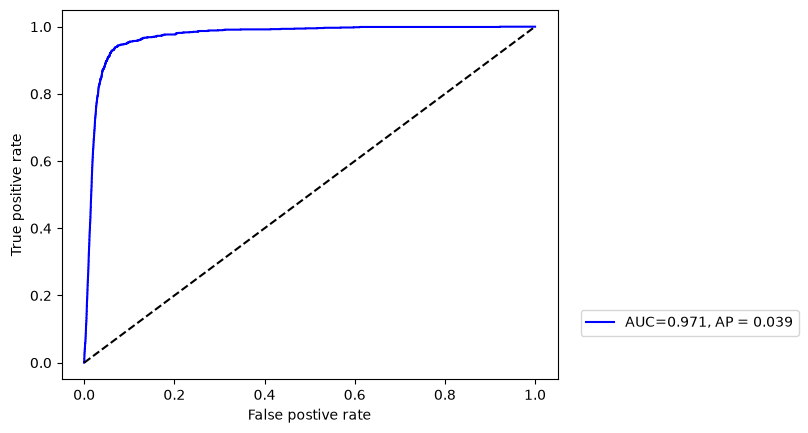

In [ ]:
print(f'validation AUC: {valid_auc}')
print(f'validation AP: {valid_ap}')
print(f'\n')

plt.plot(valid_fpr, valid_tpr,'b', label = f'AUC={"%.3f"%valid_auc}, AP = {"%.3f"%valid_ap}')
plt.plot(np.linspace(0,1,3),np.linspace(0,1,3),'k--')
plt.xlabel('False postive rate')
plt.ylabel('True positive rate')
plt.legend(loc = 'lower right', bbox_to_anchor = (1.5,0.1))
plt.show()

In [ ]:
# test--predicted edge scores: probability of being of class "1" (real edge)
test_preds = link_classifier.predict_proba(test_edge_embs)[:,1]

test_auc = roc_auc_score(test_labels, test_preds)
test_ap = average_precision_score(test_labels, test_preds)
test_fpr, test_tpr, _ = roc_curve(test_labels,test_preds)

test AUC: 0.9689339057970985
test AP: 0.0394599441335745




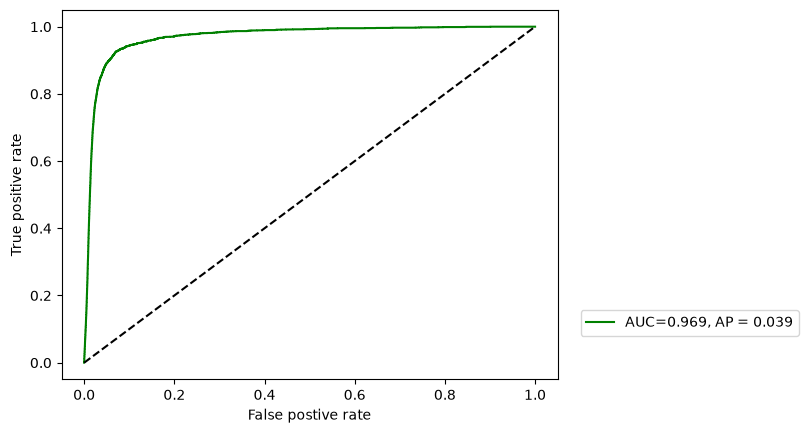

In [ ]:
print(f'test AUC: {test_auc}')
print(f'test AP: {test_ap}')
print(f'\n')

plt.plot(test_fpr, test_tpr,'g', label = f'AUC={"%.3f"%test_auc}, AP = {"%.3f"%test_ap}')
plt.plot(np.linspace(0,1,3),np.linspace(0,1,3),'k--')
plt.xlabel('False postive rate')
plt.ylabel('True positive rate')
plt.legend(loc = 'lower right', bbox_to_anchor = (1.5,0.1))
plt.show()

checking precision_recall curve

In [ ]:
#valid_pr, valid_re, _ = precision_recall_curve(valid_labels, valid_preds)
#test_pr, test_re, _ = precision_recall_curve(test_labels, test_preds)

#plt.plot(valid_pr, valid_re,'b', label = f'AP = {"%.3f"%valid_ap}')
#plt.xlabel('Recall')
#plt.ylabel('Precision')
#plt.legend(loc = 'lower right', bbox_to_anchor = (1.3,0.1))
#plt.show()

cross validate

In [ ]:
#from sklearn.model_selection import cross_validate

#cv_results = cross_validate(link_classifier, train_edge_embs, train_labels, cv = 10, scoring=('roc_auc', 'average_precision'))

In [ ]:
#cv_results

In [ ]:
#retraining
#link_classifier.fit(train_edge_embs,train_labels)

In [ ]:
# test--predicted edge scores: probability of being of class "1" (real edge)
#test_preds = link_classifier.predict_proba(test_edge_embs)[:,1]

#test_auc = roc_auc_score(test_labels, test_preds)
#test_ap = average_precision_score(test_labels, test_preds)
#test_fpr, test_tpr, _ = roc_curve(test_labels,test_preds)

In [ ]:
#print(f'test AUC: {test_auc}')
#print(f'test AP: {test_ap}')
#print(f'\n')

#plt.plot(test_fpr, test_tpr,'g', label = f'AUC={"%.3f"%test_auc}, AP = {"%.3f"%test_ap}')
#plt.plot(np.linspace(0,1,3),np.linspace(0,1,3),'k--')
#plt.xlabel('False postive rate')
#plt.ylabel('True positive rate')
#plt.legend(loc = 'lower right', bbox_to_anchor = (1.5,0.1))
#plt.show()

In [ ]:
np.savetxt(f'results_plot/n2v_fpr.csv',test_fpr)
np.savetxt(f'results_plot/n2v_tpr.csv',test_tpr)